<a href="https://colab.research.google.com/github/rafidhadizuhair/rafidhadizuhair.github.io/blob/main/Pertemuan06dantugas06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 4. Bagging dengan Decision Tree
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

# 5. Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',  # Memastikan menggunakan tanda kutip standar
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 6. Perbandingan Akurasi
print("=" * 50)
print("Perbandingan Akurasi:")
print(f"Decision Tree : {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging       : {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest : {accuracy_score(y_test, rf_pred):.4f}")

# 7. Feature Importance dari Random Forest
importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importance:")
print(importance.head())

Perbandingan Akurasi:
Decision Tree : 0.9415
Bagging       : 0.9591
Random Forest : 0.9708

Top 5 Feature Importance:
                 feature  importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975


Perbandingan Boosting Methods:
AdaBoost          : 0.9708
Gradient Boosting : 0.9591


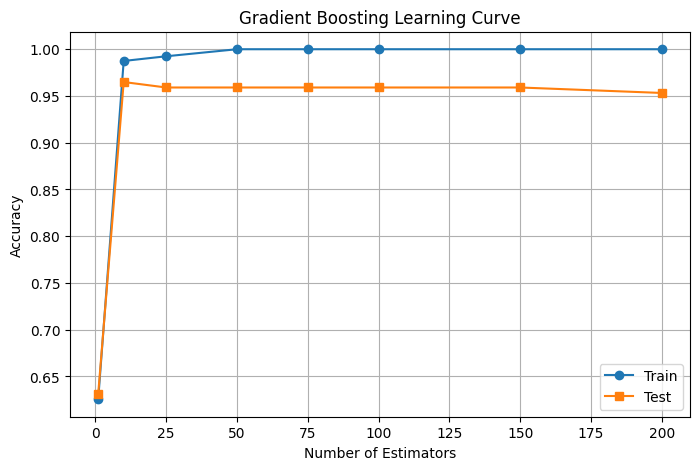

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Pastikan data X_train, X_test, y_train, y_test, dan data.feature_names
# sudah didefinisikan dari langkah sebelumnya.

# 1. AdaBoost (base estimator = decision stump)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), # decision stump
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# 2. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# 3. Feature Importance dari Gradient Boosting
gb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

# 4. Evaluasi
print("=" * 50)
print("Perbandingan Boosting Methods:")
print(f"AdaBoost          : {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting : {accuracy_score(y_test, gb_pred):.4f}")

# 5. Learning Curve
train_scores = []
test_scores = []
estimators_list = [1, 10, 25, 50, 75, 100, 150, 200]

for n in estimators_list:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_temp.fit(X_train, y_train)
    train_scores.append(gb_temp.score(X_train, y_train))
    test_scores.append(gb_temp.score(X_test, y_test))

# 6. Visualisasi Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(estimators_list, train_scores, label='Train', marker='o')
plt.plot(estimators_list, test_scores, label='Test', marker='s')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

 PERBANDINGAN SEMUA METODE 
Single Decision Tree : 0.9415
Bagging              : 0.9591
Random Forest        : 0.9708
AdaBoost             : 0.9708
Gradient Boosting    : 0.9591
Stacking             : 0.9825


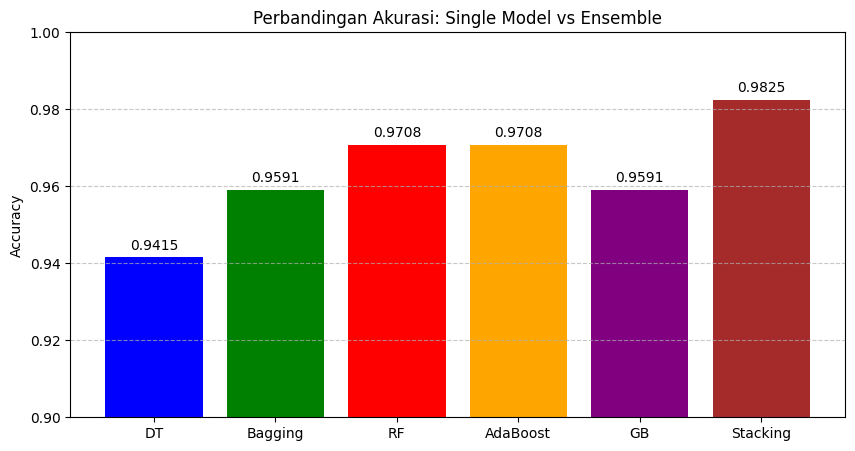

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Definisikan Base Models (Model Dasar)
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# 2. Meta-learner (Model yang menggabungkan hasil prediksi base models)
meta_learner = LogisticRegression(max_iter=1000)

# 3. Stacking Classifier
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,                      # cross-validation untuk generate meta-features
    stack_method='predict_proba' # menggunakan probabilitas untuk akurasi lebih baik
)

# 4. Pelatihan Model
stacking.fit(X_train, y_train)
stacking_pred = stacking.predict(X_test)

# 5. Perbandingan Semua Metode
print("=" * 50)
print(" PERBANDINGAN SEMUA METODE ")
print("=" * 50)
print(f"Single Decision Tree : {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging              : {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest        : {accuracy_score(y_test, rf_pred):.4f}")
print(f"AdaBoost             : {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting    : {accuracy_score(y_test, gb_pred):.4f}")
print(f"Stacking             : {accuracy_score(y_test, stacking_pred):.4f}")

# 6. Visualisasi Perbandingan
models = ['DT', 'Bagging', 'RF', 'AdaBoost', 'GB', 'Stacking']
scores = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, bagging_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, ada_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, stacking_pred)
]

plt.figure(figsize=(10, 5))
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
bars = plt.bar(models, scores, color=colors)

plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi: Single Model vs Ensemble')
plt.ylim(0.9, 1.0) # Fokus pada range akurasi tinggi

# Menambahkan label nilai di atas bar
for i, v in enumerate(scores):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# 1. List model yang akan dibandingkan
# Pastikan variabel 'stacking' sudah didefinisikan dari kode sebelumnya
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Stacking': stacking
}

# 2. Cross-validation dengan 5-fold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

print("Memulai proses Cross-Validation...")

# 3. Iterasi untuk setiap model
for name, model in models.items():
    start_time = time.time()

    # Menggunakan seluruh X dan y untuk Cross-Validation yang fair
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    elapsed_time = time.time() - start_time

    results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std(),
        'Training Time (s)': elapsed_time
    })

# 4. Menampilkan hasil dalam DataFrame
results_df = pd.DataFrame(results).round(4)
print("\n" + "=" * 60)
print("HASIL PERBANDINGAN CROSS-VALIDATION")
print("=" * 60)
print(results_df.to_string(index=False))

# 5. Kesimpulan
best_model = results_df.loc[results_df['Mean Accuracy'].idxmax(), 'Model']
print("-" * 60)
print(f"Model terbaik berdasarkan CV: {best_model}")
print("=" * 60)

Memulai proses Cross-Validation...

HASIL PERBANDINGAN CROSS-VALIDATION
            Model  Mean Accuracy    Std  Training Time (s)
    Decision Tree         0.9332 0.0162             0.2226
    Random Forest         0.9578 0.0102             2.9951
         AdaBoost         0.9736 0.0124             4.0628
Gradient Boosting         0.9613 0.0106             4.6523
         Stacking         0.9596 0.0143            12.3096
------------------------------------------------------------
Model terbaik berdasarkan CV: AdaBoost


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. LOAD DAN PREPROCESSING DATASET TITANIC
df = sns.load_dataset('titanic')

# Memilih fitur yang relevan dan membersihkan data
# Kita ambil: class (pclass), sex, age, sibsp, parch, fare, embarked
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# Mengisi nilai yang hilang
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Mengubah data kategorikal menjadi numerik
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. IMPLEMENTASI MODEL

# a. Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# b. Random Forest (dengan Tuning n_estimators dan max_depth)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

# c. Gradient Boosting (dengan Tuning learning_rate dan n_estimators)
gb_param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=3)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_

# d. Stacking (Minimal 3 base models)
base_models = [
    ('rf', rf_best),
    ('svc', SVC(probability=True, random_state=42)),
    ('gb', gb_best)
]
stacking = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stacking.fit(X_train, y_train)

# 3. EVALUASI DAN PERBANDINGAN
models = {
    'Decision Tree': dt,
    'Random Forest': rf_best,
    'Gradient Boosting': gb_best,
    'Stacking': stacking
}

report_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    report_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(report_data).round(4)

print("="*60)
print("LAPORAN PERBANDINGAN MODEL - DATASET TITANIC")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# 4. ANALISIS SINGKAT
print("\nANALISIS:")
print("1. Decision Tree biasanya memiliki akurasi terendah karena mudah overfitting.")
print("2. Random Forest lebih stabil karena merata-ratakan banyak pohon.")
print("3. Gradient Boosting unggul jika data memiliki pola kompleks karena memperbaiki error secara sekuensial.")
print("4. Stacking sering kali menjadi yang terbaik karena menggabungkan keunggulan berbagai jenis algoritma.")

LAPORAN PERBANDINGAN MODEL - DATASET TITANIC
            Model  Accuracy  Precision  Recall  F1-Score
    Decision Tree    0.7821     0.7273  0.7568    0.7417
    Random Forest    0.8101     0.8125  0.7027    0.7536
Gradient Boosting    0.7989     0.8276  0.6486    0.7273
         Stacking    0.8045     0.8305  0.6622    0.7368

ANALISIS:
1. Decision Tree biasanya memiliki akurasi terendah karena mudah overfitting.
2. Random Forest lebih stabil karena merata-ratakan banyak pohon.
3. Gradient Boosting unggul jika data memiliki pola kompleks karena memperbaiki error secara sekuensial.
4. Stacking sering kali menjadi yang terbaik karena menggabungkan keunggulan berbagai jenis algoritma.
